# Pengenalan Data Science untuk Ekonomi dan Bisnis
### Seminar untuk Dosen FEB — Departemen Ekonomi

**Studi kasus:** data nilai tukar Indonesia dari FRED (Federal Reserve Bank of St. Louis)

Notebook ini dirancang untuk peserta yang **belum pernah melakukan coding**. Karena itu, kode dibuat bertahap dan setiap blok kode disertai penjelasan baris demi baris.

### Dataset utama
1. **CCUSMA02IDM618N** — *Currency Conversions: US Dollar Exchange Rate: Average of Daily Rates: National Currency: USD for Indonesia*. Frekuensi bulanan, satuan Rupiah per USD, tidak disesuaikan musiman; sumber data yang ditampilkan FRED adalah OECD.  
2. **FXRATEIDA618NUPN** — *Exchange Rate to U.S. Dollar for Indonesia*. Frekuensi tahunan, satuan unit mata uang nasional per USD, tidak disesuaikan musiman; sumber yang ditampilkan FRED adalah University of Pennsylvania / Penn World Table 7.1.

> **Catatan akademik:** kedua seri sama-sama berbicara tentang nilai tukar, tetapi berasal dari sumber, frekuensi, dan periode yang berbeda. Karena itu, kita tidak langsung menganggap keduanya identik atau dapat dipertukarkan. Salah satu tujuan notebook ini adalah menunjukkan mengapa memahami *metadata* dan proses pembentukan data sama pentingnya dengan membaca angka.

**Sumber resmi:** FRED — Federal Reserve Bank of St. Louis.  
- CCUSMA02IDM618N: https://fred.stlouisfed.org/series/CCUSMA02IDM618N  
- FXRATEIDA618NUPN: https://fred.stlouisfed.org/series/FXRATEIDA618NUPN


## Tujuan pembelajaran

Setelah menyelesaikan notebook ini, peserta diharapkan mampu:

1. membedakan orientasi ekonometrika tradisional dan Data Science;
2. menjelaskan hubungan Data Science, Machine Learning, dan Deep Learning;
3. mengenali ekosistem Python untuk analisis ekonomi;
4. membaca data CSV, JSON, dan API;
5. mengenali beberapa tipe data: teks, time-series, gambar, dan graf;
6. membedakan data primer dan sekunder;
7. memahami proses *data acquisition*;
8. menjelaskan mengapa *data preprocessing* penting;
9. memilih preprocessing sesuai karakteristik data;
10. menangani *missing values* dan *outliers* secara bertanggung jawab;
11. melakukan transformasi dan penggabungan dataset.


# 1. Ekonometrika Tradisional vs Data Science

Keduanya tidak perlu diposisikan sebagai dua pendekatan yang saling meniadakan.

**Ekonometrika** umumnya berangkat dari pertanyaan ekonomi, teori, model statistik, identifikasi hubungan, estimasi parameter, pengujian hipotesis, dan tergantung desain penelitian hingga analisis kausal.

**Data Science** lebih luas dalam pipeline-nya: memperoleh data, membersihkan data, mengeksplorasi pola, membangun model prediktif/algoritmik, mengevaluasi performa, dan mengubah hasil menjadi insight atau keputusan.

Perbedaan yang penting bagi mahasiswa ekonomi bukan "mana yang lebih modern", tetapi **apa tujuan analisisnya**.

| Dimensi | Ekonometrika | Data Science |
|---|---|---|
| Titik awal | Teori & pertanyaan ekonomi | Problem + data |
| Fokus umum | Estimasi, inferensi, hubungan/kausalitas | Prediksi, pattern discovery, automation |
| Model | Sering menekankan interpretabilitas | Dapat menggunakan model sederhana sampai kompleks |
| Evaluasi | Asumsi, inferensi, robustness | Generalisasi, error, validation |
| Risiko | Endogeneity, omitted variables, specification | Overfitting, leakage, bias |
| Output | Parameter & interpretasi ekonomi | Prediksi, segmentasi, insight, sistem |

**Prinsip:** tujuan penelitian menentukan pendekatan; bukan sebaliknya.


# 2. Data Science vs Machine Learning vs Deep Learning

Gunakan cara berpikir bertingkat:

**Data Science** → bidang/proses yang menggabungkan data, statistik, komputasi, dan pengetahuan domain untuk menghasilkan insight.

**Machine Learning (ML)** → keluarga metode yang memungkinkan komputer mempelajari pola dari data untuk melakukan prediksi atau menemukan struktur.

**Deep Learning (DL)** → bagian dari ML yang menggunakan neural network berlapis banyak dan sangat populer untuk gambar, teks, suara, dan data kompleks lainnya.

Secara konseptual:
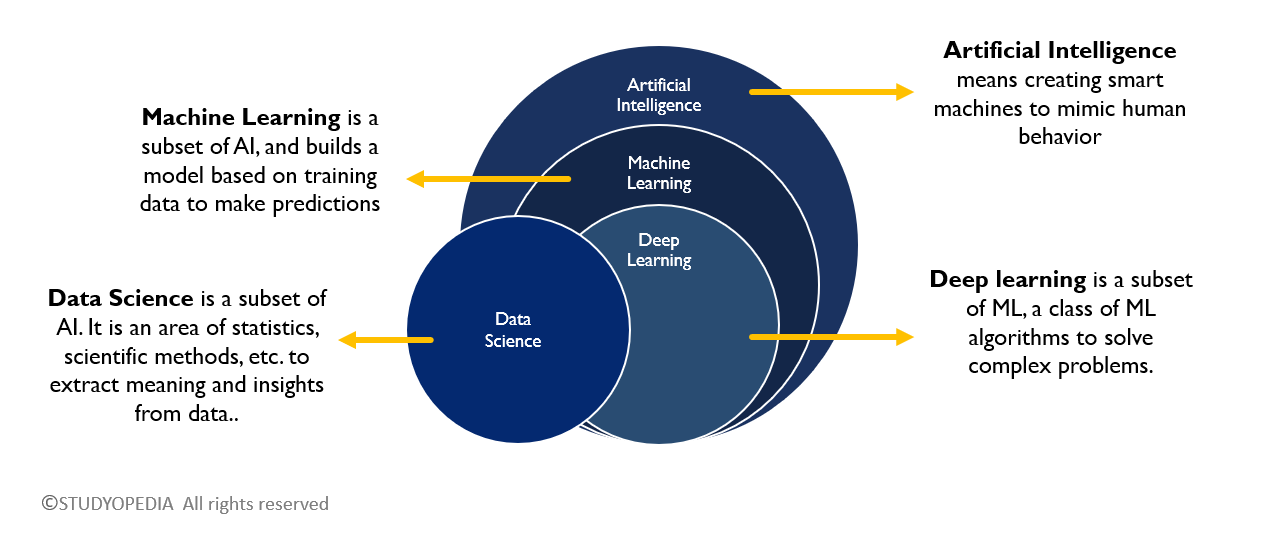
> **Deep Learning ⊂ Machine Learning ⊂ Artificial Intelligence**

Sementara itu, **Data Science tidak identik dengan AI**. Data Science dapat dilakukan tanpa ML, misalnya ketika kita hanya melakukan data cleaning, EDA, visualisasi, atau analisis statistik.


# 3. Mengenal Ekosistem Python

Untuk seminar ekonomi, beberapa library yang paling penting:

- **Python** — bahasa pemrograman.
- **NumPy** — komputasi numerik dan array.
- **Pandas** — tabel/DataFrame, cleaning, transformasi, dan penggabungan data.
- **Matplotlib** — visualisasi yang sangat fleksibel.
- **Seaborn** — visualisasi statistik yang praktis untuk EDA.
- **Scikit-learn** — preprocessing, machine learning, dan evaluasi.
- **Requests** — mengambil data dari web/API.
- **Jupyter/Google Colab** — lingkungan notebook yang menggabungkan kode, teks, dan output.

Kita akan memakai **Pandas + Matplotlib + Seaborn** sebagai fondasi praktik.


## 3.1 Menyiapkan library

Sebelum membaca data, kita memanggil library yang dibutuhkan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat grafik tampil langsung di dalam notebook
%matplotlib inline

### Penjelasan baris per baris

- `import pandas as pd` → memanggil **Pandas** untuk mengolah data berbentuk tabel.
- `import numpy as np` → memanggil **NumPy** untuk perhitungan numerik dalam Python.
- `import matplotlib.pyplot as plt` → memanggil Matplotlib untuk membuat grafik.
- `import seaborn as sns` → memanggil Seaborn untuk visualisasi dan eksplorasi statistik.
- `%matplotlib inline` → memastikan grafik tampil langsung di bawah cell pada Jupyter Notebook.

**Kebiasaan penting:** nama pendek seperti `pd`, `np`, `plt`, dan `sns` adalah konvensi umum. Tujuannya membuat kode lebih ringkas, bukan mengubah fungsi library.


# 4. Data Acquisition dan Membaca Berbagai Format

Dalam Data Science, kita sering memperoleh data melalui beberapa jalur:

1. **CSV** — sederhana dan sangat umum untuk data tabular.
2. **JSON** — banyak digunakan pada web dan API.
3. **API** — memungkinkan program meminta data langsung dari server.
4. Database, spreadsheet, data warehouse, dan sumber lain.

Kita mulai dari dataset FRED yang sudah disediakan dalam bentuk CSV.


## 4.1 Membaca CSV dari file lokal

Di komputer peserta, nama file dapat berbeda. Karena notebook seminar ini menggunakan dua file yang disediakan, kita definisikan nama file terlebih dahulu.

In [2]:
cc_file = "/content/sample_data/CCUSMA02IDM618N (1).csv"
fx_file = "/content/sample_data/FXRATEIDA618NUPN.csv"

cc = pd.read_csv(cc_file)
fx = pd.read_csv(fx_file)

### Penjelasan baris per baris

- `cc_file = ...` → menyimpan nama file seri bulanan ke dalam variabel `cc_file`.
- `fx_file = ...` → menyimpan nama file seri tahunan ke dalam variabel `fx_file`.
- `pd.read_csv(cc_file)` → meminta Pandas membaca file CSV tersebut menjadi sebuah **DataFrame**.
- Hasilnya disimpan sebagai `cc`.
- Hal yang sama dilakukan untuk `fx`.

**Analogi:** DataFrame dapat dibayangkan sebagai spreadsheet Excel yang dapat kita manipulasi dengan kode.


## 4.2 Melihat isi data

Langkah pertama setelah membaca data adalah **jangan langsung membuat model**. Kenali dulu datanya.

In [3]:
cc.head()


,observation_date,CCUSMA02IDM618N
0,1967-01-01,137.0
1,1967-02-01,137.0
2,1967-03-01,137.0
3,1967-04-01,137.0
4,1967-05-01,137.0


### Penjelasan

- `cc.head()` menampilkan lima baris pertama secara default.
- Tujuannya untuk memeriksa apakah file berhasil dibaca dan apakah struktur awalnya sesuai harapan.

Coba sendiri:
- `cc.head(10)` untuk 10 baris pertama.
- `cc.tail()` untuk 5 baris terakhir.


In [4]:
fx.head()


,observation_date,FXRATEIDA618NUPN
0,1960-01-01,0.075444
1,1961-01-01,0.088475
2,1962-01-01,0.243304
3,1963-01-01,0.575852
4,1964-01-01,1.227225


`fx.head()` melakukan hal yang sama untuk dataset tahunan.


## 4.3 Memeriksa ukuran dan tipe data

In [5]:
print("Ukuran CC:", cc.shape)
print("Ukuran FX:", fx.shape)

print("\nTipe data CC:")
print(cc.dtypes)

print("\nTipe data FX:")
print(fx.dtypes)

Ukuran CC: (716, 2)
Ukuran FX: (51, 2)

Tipe data CC:
observation_date     object
CCUSMA02IDM618N     float64
dtype: object

Tipe data FX:
observation_date     object
FXRATEIDA618NUPN    float64
dtype: object


### Penjelasan baris per baris

- `cc.shape` → menghasilkan pasangan `(jumlah_baris, jumlah_kolom)`.
- `print(...)` → menampilkan informasi ke layar.
- `cc.dtypes` → menunjukkan tipe data setiap kolom.
- `\n` → membuat baris baru agar output lebih mudah dibaca.

Perhatikan bahwa tanggal pada file CSV awalnya dapat terbaca sebagai `object`. Untuk analisis time-series, kita sebaiknya mengubahnya menjadi tipe tanggal.

### Penjelasan Tipe Data
- `object` → biasanya digunakan untuk data teks, termasuk tanggal yang masih terbaca sebagai teks.
- `float64` → digunakan untuk data angka desimal, seperti nilai exchange rate.
- `int64` → digunakan untuk data bilangan bulat, misalnya jumlah observasi.
- `datetime` → tipe khusus untuk tanggal/waktu, penting untuk analisis time-series.

# 5. Mengenal Tipe Data

Dalam pekerjaan Data Science, "tipe data" dapat berarti dua hal.

### A. Tipe nilai/variabel
- numerik: `int`, `float`
- teks: `str`
- kategorikal
- boolean: `True/False`
- tanggal/waktu: `datetime`

### B. Bentuk/struktur data
- **tabular**: baris dan kolom
- **time-series**: observasi memiliki dimensi waktu
- **text**: dokumen, berita, komentar
- **image**: piksel
- **graph/network**: node dan edge

Satu dataset ekonomi dapat memiliki beberapa karakteristik sekaligus. Dataset FRED kita adalah **tabular + time-series + numerik**.


## 5.1 Contoh sederhana: data teks

In [6]:
teks = "Rupiah mengalami perubahan nilai terhadap US Dollar."

print(teks)
print(type(teks))

Rupiah mengalami perubahan nilai terhadap US Dollar.
<class 'str'>


- `teks = ...` → membuat sebuah variabel berisi string.
- `print(teks)` → menampilkan isi string.
- `type(teks)` → memberi tahu Python tipe objek tersebut.

Data teks dapat dianalisis lebih lanjut dengan teknik NLP, misalnya *tokenization*, *sentiment analysis*, atau *topic modeling*.


## 5.2 Contoh time-series

In [7]:
cc["observation_date"] = pd.to_datetime(cc["observation_date"])

print(cc["observation_date"].dtype)
print(cc["observation_date"].min())
print(cc["observation_date"].max())

datetime64[ns]
1967-01-01 00:00:00
2026-08-01 00:00:00


### Penjelasan baris per baris

- `cc["observation_date"]` → memilih kolom tanggal.
- `pd.to_datetime(...)` → mengubah teks tanggal menjadi objek tanggal yang dikenali Pandas.
- `cc["observation_date"] = ...` → hasil konversi disimpan kembali ke kolom yang sama.
- `.dtype` → memeriksa tipe data setelah konversi.
- `.min()` → tanggal paling awal.
- `.max()` → tanggal paling akhir.

Ini penting karena operasi seperti pengelompokan berdasarkan tahun, *resampling*, dan perhitungan perubahan waktu membutuhkan tipe tanggal yang benar.


## 5.3 Contoh membaca gambar

Gambar sebenarnya adalah data numerik: setiap piksel menyimpan nilai intensitas/warna.

Contoh berikut hanya untuk memperkenalkan cara membaca image. Jika file gambar tidak tersedia, cell tidak perlu dijalankan.

In [8]:
# Contoh konseptual
# from PIL import Image
# image = Image.open("contoh_gambar.png")
# display(image)

# Setelah dibaca, image dapat diubah menjadi array:
# image_array = np.array(image)
# print(image_array.shape)

- `Image.open(...)` → membaca file gambar.
- `np.array(image)` → mengubah gambar menjadi array numerik.
- `shape` → menunjukkan dimensi array, misalnya tinggi × lebar × channel warna.

Dalam ekonomi, citra satelit dapat digunakan untuk mengukur aktivitas ekonomi, penggunaan lahan, atau perkembangan wilayah.


## 5.4 Contoh data graph/network

Graph terdiri dari **node** dan **edge**. Contoh sederhana: node = perusahaan, edge = hubungan kepemilikan atau transaksi.

Contoh konseptual:

In [9]:
# Contoh konseptual
# import networkx as nx
# G = nx.Graph()
# G.add_edge("Perusahaan A", "Perusahaan B")
# G.add_edge("Perusahaan B", "Perusahaan C")
# print(G.nodes())
# print(G.edges())

Data graph cocok untuk pertanyaan tentang jaringan: hubungan antarperusahaan, jaringan perdagangan, transportasi, atau interaksi sosial.


# 6. Data Primer vs Data Sekunder

### Data primer
Data dikumpulkan langsung oleh peneliti untuk tujuan penelitian tertentu.

Contoh:
- survei yang kita rancang sendiri;
- eksperimen;
- wawancara;
- pengukuran lapangan.

**Kelebihan:** pertanyaan dan definisi variabel dapat disesuaikan dengan kebutuhan penelitian.

**Kekurangan:** membutuhkan waktu, biaya, desain sampling, dan pengelolaan lapangan.

### Data sekunder
Data sudah dikumpulkan oleh pihak lain dan kemudian digunakan oleh peneliti.

Contoh:
- FRED;
- BPS;
- Bank Indonesia;
- World Bank;
- OECD;
- data administrasi pemerintah;
- dataset penelitian yang dipublikasikan.

Dataset FRED dalam seminar ini adalah contoh **data sekunder**.

**Catatan:** data sekunder bukan berarti data "buruk". Tantangannya adalah memahami bagaimana data tersebut dikumpulkan, definisinya, unit pengukurannya, serta keterbatasannya.


# 7. Bagaimana Mendapatkan Data (*Data Acquisition*)?

Secara umum, alurnya:

**Pertanyaan penelitian → sumber data → akses → dokumentasi → download/collect → validasi → penyimpanan**

Sebelum mengunduh data, tanyakan:

1. Siapa penerbit/source?
2. Apa definisi variabel?
3. Apa unit analisis?
4. Apa frekuensi data?
5. Apa periode observasi?
6. Apakah ada missing value?
7. Apakah data dapat digunakan kembali dan bagaimana aturan sitasinya?

Untuk FRED, metadata seri sangat membantu karena halaman seri menjelaskan source, unit, frequency, seasonal adjustment, dan catatan lainnya.


## 7.1 Data acquisition langsung dari URL CSV FRED

Selain file lokal, kita dapat meminta Pandas membaca data CSV dari URL. FRED menyediakan endpoint `fredgraph.csv` untuk seri tertentu.

Contoh:

In [10]:
fred_csv_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CCUSMA02IDM618N"

cc_online = pd.read_csv(fred_csv_url)

cc_online.head()

,observation_date,CCUSMA02IDM618N
0,1967-01-01,137.0
1,1967-02-01,137.0
2,1967-03-01,137.0
3,1967-04-01,137.0
4,1967-05-01,137.0


### Penjelasan baris per baris

- `fred_csv_url = ...` → menyimpan alamat data CSV FRED.
- `pd.read_csv(fred_csv_url)` → Pandas membaca CSV langsung dari internet.
- `cc_online` → DataFrame hasil pembacaan.
- `head()` → memeriksa beberapa baris pertama.

**Perbedaan dengan file lokal:** file lokal adalah snapshot yang sudah kita download; URL adalah cara mengambil data dari sumber online ketika notebook dijalankan.


## 7.2 Contoh JSON

JSON banyak digunakan untuk pertukaran data di web. Struktur JSON dapat berupa pasangan `key: value`, list, atau nested object.

In [11]:
import json

contoh_json = '''
{
    "negara": "Indonesia",
    "mata_uang": "Rupiah",
    "tahun": 2026,
    "nilai": 17000
}
'''

data_json = json.loads(contoh_json)

print(data_json["negara"])
print(data_json["nilai"])

Indonesia
17000


### Penjelasan

- `import json` → memanggil library bawaan Python untuk JSON.
- `contoh_json = '''...'''` → membuat contoh teks berformat JSON.
- `json.loads(...)` → mengubah teks JSON menjadi objek Python.
- `data_json["negara"]` → mengambil nilai berdasarkan key `negara`.
- `data_json["nilai"]` → mengambil nilai berdasarkan key `nilai`.

Konsep penting: **CSV cenderung tabular; JSON lebih fleksibel untuk struktur data bertingkat.**


## 7.3 Contoh API FRED

FRED menyediakan Web Services/API untuk mengambil observasi secara programatik. Dokumentasi resmi menyatakan bahwa endpoint observasi dapat mengembalikan XML, JSON, XLSX, atau CSV. **FRED API membutuhkan API key.**

Jangan menulis API key langsung di notebook yang akan dibagikan ke peserta.

In [12]:
# Contoh pola penggunaan API — tidak dijalankan tanpa API key.
#
# import os
# import requests
#
# api_key = os.getenv("FRED_API_KEY")
#
# params = {
#     "series_id": "CCUSMA02IDM618N",
#     "api_key": api_key,
#     "file_type": "json"
# }
#
# response = requests.get(
#     "https://api.stlouisfed.org/fred/series/observations",
#     params=params
# )
#
# data = response.json()
# print(data["observations"][:3])

### Penjelasan konsep

- `os.getenv("FRED_API_KEY")` → mengambil API key dari environment variable, bukan menuliskannya di kode.
- `params = {...}` → menyiapkan parameter request.
- `requests.get(...)` → mengirim HTTP GET request ke server FRED.
- `response.json()` → mengubah respons JSON menjadi objek Python.
- `data["observations"]` → mengambil daftar observasi.

Untuk seminar pemula, **CSV lebih mudah untuk langkah pertama**, sedangkan API diperkenalkan sebagai mekanisme otomasi *data acquisition*.

Dokumentasi FRED: https://fred.stlouisfed.org/docs/api/fred/series_observations.html


# 8. Kenapa Data Preprocessing Penting?

Model tidak "mengerti" konteks ekonomi secara otomatis. Model menerima representasi numerik yang kita berikan.

Preprocessing diperlukan untuk:

- memperbaiki tipe data;
- menangani missing values;
- mendeteksi duplikasi;
- menangani nilai yang tidak masuk akal;
- menyamakan skala bila diperlukan;
- mengubah variabel kategorikal menjadi bentuk yang dapat diproses model;
- menyelaraskan periode/frekuensi;
- mencegah *data leakage*.

**Prinsip:** preprocessing bukan pekerjaan kosmetik. Keputusan preprocessing dapat mengubah hasil analisis.


# 9. Preprocessing Sesuai Tipe Data

| Tipe data | Contoh preprocessing |
|---|---|
| Tabular numerik | missing value, outlier, scaling, transformasi |
| Kategorikal | standardisasi label, encoding |
| Time-series | parsing tanggal, sorting, frequency alignment, lag/rolling |
| Text | cleaning, tokenization, stopwords, vectorization |
| Image | resize, normalization, augmentation |
| Graph | validasi node/edge, deduplikasi edge, graph features |

Tidak semua langkah harus dilakukan. Pilih berdasarkan pertanyaan penelitian, sifat data, dan model yang akan digunakan.


## 9.1 Memeriksa missing values pada dataset FRED

Mari lihat kondisi aktual kedua file.

In [13]:
print("Missing value pada CC:")
print(cc.isna().sum())

print("\nMissing value pada FX:")
print(fx.isna().sum())

Missing value pada CC:
observation_date    0
CCUSMA02IDM618N     0
dtype: int64

Missing value pada FX:
observation_date    0
FXRATEIDA618NUPN    0
dtype: int64


- `isna()` membuat indikator apakah suatu nilai kosong.
- `.sum()` menghitung jumlah nilai kosong per kolom.
- `\n` hanya digunakan untuk membuat output lebih rapi.

**Penting:** jika hasil menunjukkan nol, jangan membuat-buat proses imputasi pada dataset utama. Kita dapat membuat contoh kecil terpisah untuk pembelajaran.


# 10. Missing Values

Beberapa strategi:

1. **Drop** observasi/kolom — bila kehilangan data tidak merusak representasi dan jumlahnya wajar.
2. **Imputasi mean/median** — dapat digunakan pada kondisi tertentu.
3. **Forward/backward fill** — kadang relevan untuk time-series, tetapi harus mempertimbangkan konteks.
4. **Interpolation** — dapat berguna untuk seri waktu tertentu.
5. **Model-based imputation** — lebih kompleks.
6. **Missingness sebagai informasi** — terkadang fakta bahwa data hilang sendiri memiliki makna.

Tidak ada satu metode yang selalu benar.

### Contoh teaching dataset


In [14]:
contoh = pd.DataFrame({
    "pendapatan": [5, 6, np.nan, 8, 9]
})

print(contoh)

   pendapatan
0         5.0
1         6.0
2         NaN
3         8.0
4         9.0


- Kita membuat DataFrame kecil agar peserta dapat melihat konsep missing value tanpa mengubah dataset FRED asli.
- `np.nan` adalah representasi nilai numerik yang hilang.

Contoh imputasi median:

In [15]:
median_pendapatan = contoh["pendapatan"].median()

contoh["pendapatan_imputasi"] = contoh["pendapatan"].fillna(median_pendapatan)

print(contoh)

   pendapatan  pendapatan_imputasi
0         5.0                  5.0
1         6.0                  6.0
2         NaN                  7.0
3         8.0                  8.0
4         9.0                  9.0


### Penjelasan

- `.median()` menghitung median.
- `.fillna(...)` mengganti nilai yang kosong.
- Hasil disimpan ke kolom baru sehingga **data asli tetap dapat dibandingkan**.

Dalam penelitian nyata, keputusan imputasi harus dijelaskan dan didukung alasan substantif/statistik.


# 11. Outliers

Outlier adalah observasi yang sangat berbeda dari sebagian besar data.

Tetapi:

> **Outlier ≠ otomatis error.**

Dalam ekonomi, nilai ekstrem dapat merupakan fenomena nyata: krisis, perubahan rezim, shock harga, atau perusahaan dengan ukuran yang sangat besar.

Salah satu metode sederhana untuk **mendeteksi** outlier adalah IQR:

- Q1 = kuartil 25%
- Q3 = kuartil 75%
- IQR = Q3 − Q1
- batas bawah = Q1 − 1.5 × IQR
- batas atas = Q3 + 1.5 × IQR

Metode ini membantu *screening*, bukan otomatis menentukan bahwa observasi harus dihapus.


In [16]:
nilai = pd.Series([10, 11, 12, 12, 13, 14, 15, 100])

Q1 = nilai.quantile(0.25)
Q3 = nilai.quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outlier = nilai[(nilai < batas_bawah) | (nilai > batas_atas)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Outlier terdeteksi:")
print(outlier)

Q1: 11.75
Q3: 14.25
IQR: 2.5
Outlier terdeteksi:
7    100
dtype: int64


### Penjelasan baris per baris

- `pd.Series(...)` → membuat satu kolom data sederhana.
- `.quantile(0.25)` → mencari Q1.
- `.quantile(0.75)` → mencari Q3.
- `Q3 - Q1` → menghitung IQR.
- Batas bawah/atas → menentukan area screening.
- Kondisi `|` berarti **atau**.
- `nilai[(...)]` → memilih observasi yang memenuhi kondisi.

Setelah terdeteksi, langkah berikutnya adalah **investigasi**: apakah outlier merupakan kesalahan pencatatan atau fenomena ekonomi yang memang terjadi?


# 12. Transformasi Data

Transformasi dilakukan ketika representasi awal data belum sesuai dengan kebutuhan analisis.

Contoh:

- mengubah string tanggal menjadi datetime;
- membuat `year`;
- membuat pertumbuhan (*growth rate*);
- log transformation;
- standardization;
- agregasi bulanan menjadi tahunan;
- membuat lag atau rolling average pada time-series.

Kita akan melakukan transformasi yang relevan dengan dua seri FRED.


## 12.1 Membuat variabel tahun

In [18]:
cc["observation_date"] = pd.to_datetime(cc["observation_date"])
fx["observation_date"] = pd.to_datetime(fx["observation_date"])

cc["year"] = cc["observation_date"].dt.year
fx["year"] = fx["observation_date"].dt.year

cc[["observation_date", "year"]].head()

,observation_date,year
0,1967-01-01,1967
1,1967-02-01,1967
2,1967-03-01,1967
3,1967-04-01,1967
4,1967-05-01,1967


- `.dt.year` mengambil komponen tahun dari kolom datetime.
- Variabel `year` akan berguna ketika kita ingin menyamakan frekuensi bulanan dengan data tahunan.


## 12.2 Mengubah data bulanan menjadi tahunan

Dataset `CCUSMA02IDM618N` bersifat **bulanan**, sedangkan `FXRATEIDA618NUPN` bersifat **tahunan**. Agar dapat digabung berdasarkan tahun, kita perlu menentukan bagaimana data bulanan diagregasikan.

Untuk demonstrasi ini, kita menggunakan **rata-rata tahunan** dari observasi bulanan.

Ini adalah keputusan metodologis: agregasi harus dipilih berdasarkan makna variabel dan tujuan analisis.

In [19]:
cc_annual = (
    cc.groupby("year", as_index=False)["CCUSMA02IDM618N"]
      .mean()
      .rename(columns={
          "CCUSMA02IDM618N": "CCUSMA02IDM618N_annual_mean"
      })
)

cc_annual.head()

,year,CCUSMA02IDM618N_annual_mean
0,1967,149.583333
1,1968,296.291667
2,1969,326.000000
3,1970,362.833333
4,1971,391.875000


### Penjelasan baris per baris

- `cc.groupby("year", as_index=False)` → mengelompokkan observasi berdasarkan tahun.
- `["CCUSMA02IDM618N"]` → memilih variabel nilai tukar.
- `.mean()` → menghitung rata-rata bulanan untuk setiap tahun.
- `.rename(...)` → memberi nama baru agar jelas bahwa nilai tersebut adalah rata-rata tahunan.
- Tanda kurung luar memungkinkan kode ditulis beberapa baris agar mudah dibaca.

**Peringatan:** jangan melakukan agregasi hanya karena ingin "membuat data cocok". Tanyakan terlebih dahulu apakah agregasi tersebut memiliki makna ekonomi.


# 13. Menggabungkan Dataset (*Dataset Integration*)

Setelah frekuensinya disejajarkan, kita dapat menggabungkan kedua dataset.

Kita akan menggunakan `year` sebagai *key*.

In [20]:
merged = pd.merge(
    cc_annual,
    fx,
    on="year",
    how="inner"
)

merged.head()

,year,CCUSMA02IDM618N_annual_mean,observation_date,FXRATEIDA618NUPN
0,1967,149.583333,1967-01-01,149.583298
1,1968,296.291667,1968-01-01,296.291687
2,1969,326.000000,1969-01-01,326.000000
3,1970,362.833333,1970-01-01,362.833333
4,1971,391.875000,1971-01-01,391.875000


### Penjelasan baris per baris

- `pd.merge(...)` → fungsi Pandas untuk menggabungkan DataFrame.
- `cc_annual` → dataset bulanan yang sudah diagregasi tahunan.
- `fx` → dataset tahunan.
- `on="year"` → kedua tabel digabung berdasarkan kolom `year`.
- `how="inner"` → hanya mempertahankan tahun yang tersedia pada **kedua** dataset.
- `merged` → DataFrame hasil penggabungan.

Dalam praktik, pilihan `inner`, `left`, `right`, atau `outer` dapat menghasilkan jumlah observasi yang berbeda. Karena itu, jenis *join* harus dipilih secara sadar.


## 13.1 Memeriksa hasil penggabungan

In [21]:
print("Ukuran dataset hasil merge:", merged.shape)
print("Periode:", merged["year"].min(), "sampai", merged["year"].max())

merged.tail()

Ukuran dataset hasil merge: (44, 4)
Periode: 1967 sampai 2010


,year,CCUSMA02IDM618N_annual_mean,observation_date,FXRATEIDA618NUPN
39,2006,9164.027344,2006-01-01,9159.32
40,2007,9139.407610,2007-01-01,9141.00
41,2008,9663.874300,2008-01-01,9698.96
42,2009,10376.833749,2009-01-01,10389.90
43,2010,9078.026535,2010-01-01,9090.43


Tujuan pemeriksaan ini adalah memastikan kita memahami **berapa banyak observasi yang tersisa** setelah proses integrasi.


# 14. Eksplorasi Awal Dataset FRED

Sekarang kita mulai melakukan EDA sederhana.

Pertanyaan pertama:

> Bagaimana perkembangan nilai tukar Rupiah terhadap USD dari waktu ke waktu?


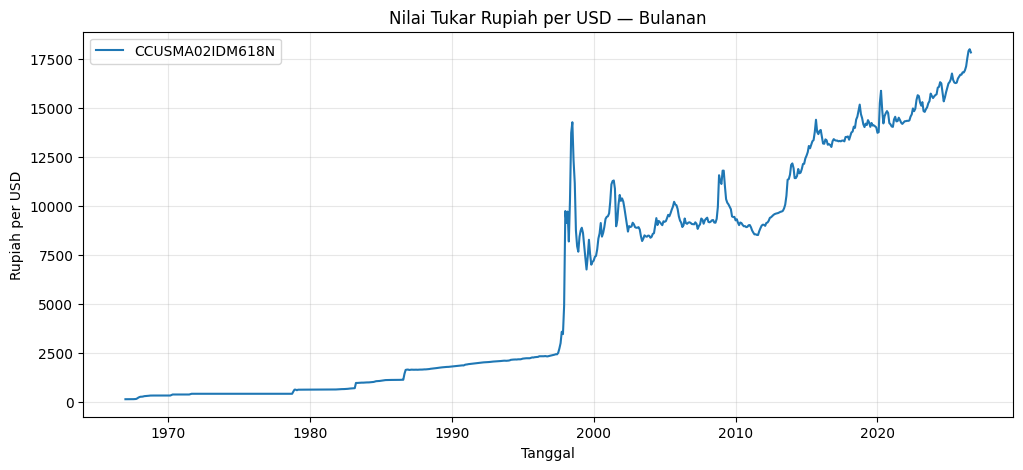

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(
    cc["observation_date"],
    cc["CCUSMA02IDM618N"],
    label="CCUSMA02IDM618N"
)

plt.title("Nilai Tukar Rupiah per USD — Bulanan")
plt.xlabel("Tanggal")
plt.ylabel("Rupiah per USD")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Penjelasan

- `plt.figure(figsize=(12, 5))` → membuat area grafik dengan ukuran tertentu.
- `plt.plot(x, y)` → membuat grafik garis.
- `x` = tanggal; `y` = nilai tukar.
- `label` → nama seri untuk legenda.
- `title`, `xlabel`, `ylabel` → memberi konteks pada grafik.
- `legend()` → menampilkan legenda.
- `grid()` → membantu membaca posisi data.
- `show()` → menampilkan grafik.

Untuk time-series, grafik garis biasanya menjadi langkah awal yang sangat informatif.


## 14.1 Membandingkan dua seri setelah penyelarasan frekuensi

Kita dapat melihat apakah pola dua seri bergerak secara mirip pada periode yang sama. Ingat bahwa keduanya berasal dari sumber dan metodologi yang berbeda.

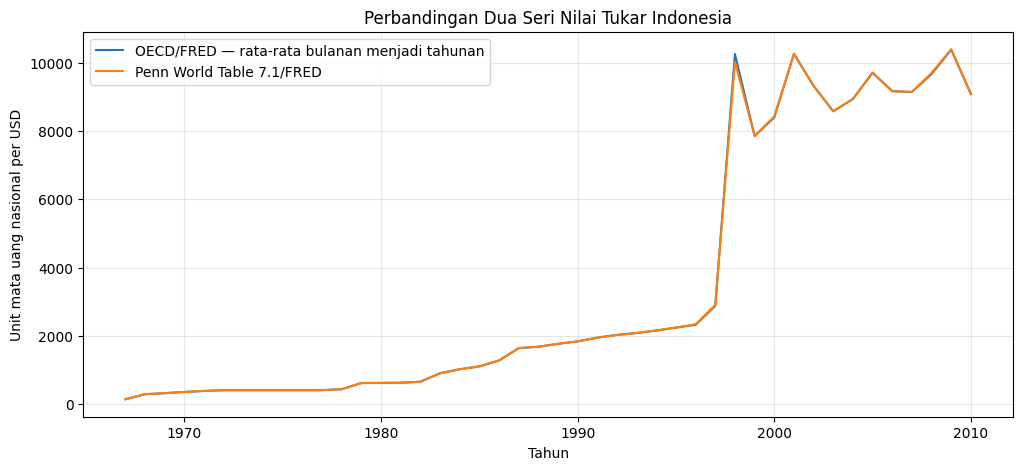

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(
    merged["year"],
    merged["CCUSMA02IDM618N_annual_mean"],
    label="OECD/FRED — rata-rata bulanan menjadi tahunan"
)

plt.plot(
    merged["year"],
    merged["FXRATEIDA618NUPN"],
    label="Penn World Table 7.1/FRED"
)

plt.title("Perbandingan Dua Seri Nilai Tukar Indonesia")
plt.xlabel("Tahun")
plt.ylabel("Unit mata uang nasional per USD")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Catatan metodologis:** grafik ini adalah alat eksplorasi, bukan bukti bahwa kedua seri mengukur konsep dengan definisi yang identik. Perbedaan sumber, frekuensi, periode, dan proses pembentukan data harus tetap diperhatikan.


# 15. Contoh Transformasi Ekonomi: Persentase Perubahan

Untuk analisis ekonomi, kita sering tertarik pada perubahan relatif daripada level.

Pandas menyediakan `.pct_change()` untuk menghitung perubahan persentase antarperiode.

In [24]:
cc["perubahan_persen"] = (
    cc["CCUSMA02IDM618N"].pct_change() * 100
)

cc[[
    "observation_date",
    "CCUSMA02IDM618N",
    "perubahan_persen"
]].head(10)

,observation_date,CCUSMA02IDM618N,perubahan_persen
0,1967-01-01,137.0,NaN
1,1967-02-01,137.0,0.000000
2,1967-03-01,137.0,0.000000
3,1967-04-01,137.0,0.000000
4,1967-05-01,137.0,0.000000
5,1967-06-01,137.0,0.000000
6,1967-07-01,137.0,0.000000
7,1967-08-01,140.5,2.554745
8,1967-09-01,146.0,3.914591
9,1967-10-01,150.0,2.739726


### Penjelasan

- `.pct_change()` → menghitung perubahan relatif terhadap observasi sebelumnya.
- `* 100` → mengubah proporsi menjadi persen.
- Observasi pertama biasanya menghasilkan `NaN` karena tidak memiliki periode sebelumnya.
- Kita menyimpan hasil sebagai kolom baru agar variabel level tetap tersedia.

Transformasi seperti ini dapat menjadi dasar untuk analisis pertumbuhan atau perubahan, tetapi definisi "growth" harus disesuaikan dengan pertanyaan ekonomi.


# 16. EDA: Statistik Deskriptif

Statistik deskriptif membantu kita mengenali skala dan distribusi data sebelum masuk ke model.

In [25]:
cc["CCUSMA02IDM618N"].describe()


,CCUSMA02IDM618N
count,716.000000
mean,6141.306889
std,5633.345434
min,137.000000
25%,637.810000
50%,2339.200648
75%,10176.994318
max,18007.565217


Output `describe()` umumnya berisi:

- `count` → jumlah observasi;
- `mean` → rata-rata;
- `std` → standar deviasi;
- `min` → nilai minimum;
- `25%`, `50%`, `75%` → kuartil;
- `max` → maksimum.

Statistik ini bukan pengganti grafik. Keduanya saling melengkapi.


# 17. Mengapa EDA Penting Sebelum Machine Learning?

Misalkan kita ingin memprediksi suatu variabel ekonomi. Sebelum memilih algoritma, kita perlu memahami:

- apakah target numerik atau kategorikal;
- apakah terdapat missing value;
- apakah distribusi sangat skewed;
- apakah ada outlier;
- apakah fitur memiliki skala yang sangat berbeda;
- apakah ada hubungan waktu;
- apakah terdapat kemungkinan *data leakage*;
- apakah data cukup representatif terhadap pertanyaan penelitian.

**Machine Learning yang baik tidak dimulai dari memilih algoritma. Ia dimulai dari memahami masalah dan data.**


# 18. Alur Kerja Data Science untuk Ekonomi

Gunakan alur berikut sebagai kerangka berpikir:

**1. Economic Question**  
↓  
**2. Data Acquisition**  
↓  
**3. Data Understanding**  
↓  
**4. Data Preprocessing**  
↓  
**5. EDA**  
↓  
**6. Feature Engineering / Transformation**  
↓  
**7. Modeling**  
↓  
**8. Evaluation**  
↓  
**9. Interpretation**  
↓  
**10. Decision / Research Conclusion**

Tidak semua proyek membutuhkan Machine Learning. Pada banyak penelitian ekonomi, proses dapat berhenti pada tahap EDA atau model statistik yang lebih sederhana jika itu sudah menjawab pertanyaan penelitian.


# 19. Ringkasan Utama

### 1. Ekonometrika dan Data Science memiliki fokus yang dapat saling melengkapi
Ekonometrika kuat untuk pertanyaan ekonomi, inferensi, dan interpretasi hubungan; Data Science memperluas pipeline ke acquisition, computation, prediction, dan pattern discovery.

### 2. Data Science ≠ Machine Learning ≠ Deep Learning
ML adalah bagian dari AI; DL adalah bagian dari ML. Data Science lebih luas dan tidak selalu membutuhkan ML.

### 3. Python adalah ekosistem
Untuk tahap awal, pahami terutama Pandas, NumPy, Matplotlib, Seaborn, dan Scikit-learn.

### 4. Data harus dipahami sebelum dianalisis
Kenali source, unit, periode, frekuensi, definisi variabel, dan metadata.

### 5. Preprocessing adalah bagian dari analisis
Missing value, outlier, transformasi, encoding, scaling, dan alignment dapat memengaruhi hasil.

### 6. Jangan menghapus data secara otomatis
Missing value dan outlier harus ditangani berdasarkan konteks statistik dan ekonomi.

### 7. Integrasi dataset membutuhkan keputusan metodologis
Ketika frekuensi berbeda, seperti bulanan dan tahunan pada dua seri FRED kita, kita harus menentukan cara agregasi yang masuk akal sebelum melakukan merge.

### 8. Insight bukan sekadar output Python
Tujuan akhirnya adalah menjawab pertanyaan ekonomi secara masuk akal, transparan, dan dapat dipertanggungjawabkan.


# 20. Take-Home Exercise

Pilih satu dataset ekonomi yang pernah digunakan dalam penelitian atau pengajaran Anda.

Jawab lima pertanyaan berikut:

1. Apa **unit analisis** dataset tersebut?
2. Apakah data tersebut **primer atau sekunder**?
3. Apa saja masalah preprocessing yang mungkin muncul?
4. Bagaimana Anda akan melakukan EDA?
5. Pertanyaan ekonomi apa yang dapat dijawab oleh dataset tersebut?

### Tantangan tambahan
Coba cari satu dataset publik dari BPS, Bank Indonesia, World Bank, OECD, atau FRED dan tuliskan:

> **Research question → data source → variables → preprocessing → EDA → potential analysis**

Inilah cara mulai berpindah dari **"belajar coding"** menjadi **"menggunakan coding untuk menjawab pertanyaan ekonomi."**


# Referensi dan Sumber Data

### FRED
- CCUSMA02IDM618N — *Currency Conversions: US Dollar Exchange Rate: Average of Daily Rates: National Currency: USD for Indonesia*  
  https://fred.stlouisfed.org/series/CCUSMA02IDM618N

- FXRATEIDA618NUPN — *Exchange Rate to U.S. Dollar for Indonesia*  
  https://fred.stlouisfed.org/series/FXRATEIDA618NUPN

### FRED API
Dokumentasi resmi:
https://fred.stlouisfed.org/docs/api/fred/series_observations.html

### Catatan penggunaan data
Periksa halaman seri FRED untuk informasi source, unit, frequency, catatan, dan ketentuan sitasi sebelum menggunakan data dalam publikasi atau materi yang dibagikan secara luas.
